# lacombe2021 — Lacombe et al. (2021) Topological Uncertainty

Per-sample uncertainty score: distance to the Fréchet-mean MST diagram of the predicted class.


## What the paper does

**Topological Uncertainty (TU)** turns a forward pass into an anomaly score *without* a test set. For each layer the paper builds the bipartite graph `|W · x|` of a sample and reads off its **minimum spanning tree** as a 0-dimensional persistence diagram. During fit it accumulates, per layer and per *predicted* class, the **Fréchet mean** (average) of those diagrams over the training set. A new input is scored by the average `L2` distance between its per-layer diagrams and the stored means for its predicted class.

**Methodology:** per-(layer, sample) MST diagram → per-(layer, class) Fréchet-mean diagram → TU = mean `L2` distance to the predicted class's mean.

**Expected result:** misclassified / out-of-distribution inputs score *higher* than correct in-distribution inputs, so TU works as an OOD detector and a distribution-shift monitor even when softmax confidence stays high (paper Fig. 5, Table 1).


## Dataset & model in the paper

- **arXiv:** [https://arxiv.org/abs/2105.04404](https://arxiv.org/abs/2105.04404)
- **Venue:** IJCAI 2021
- **Datasets used:** Synthetic + MNIST, CIFAR-10, molecular graphs.
- **Models used:** Standard MLPs / GNNs trained at the relevant task.
- **Headline result to aim for:** TU = mean over layers of L2 distance to the Frechet-mean MST diagram of the predicted class; misclassified inputs score higher than correct inputs (paper Fig. 5).
- **Reference code:** no public repo found in web search — check paper supplementary materials.

To reproduce paper numbers, replace the synthetic-data cell below with the real model snapshot / activations / trajectory.  Everything else in the notebook stays the same.


**This notebook now runs on real MNIST data.**  A tiny MLP is trained briefly and pre-synaptic activations are extracted via the toolkit's `ModelExtractor`.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # make `paper_reproduce` importable
import numpy as np
import matplotlib.pyplot as plt
import torch
from tanc import TDAPipeline
from paper_reproduce._torch_setup import (
    load_mnist, load_fashion_mnist, load_cifar10, load_cifar100,
    SmallMLP, SmallCNN, CNN_FCN, train_briefly, extract_snapshot, pick_device,
)
np.random.seed(0); torch.manual_seed(0)
DEVICE = pick_device()                      # 'cuda' → 'mps' (Apple GPU) → 'cpu'


## 1. Train a small MLP on MNIST


In [2]:
X_tr, y_tr = load_mnist('train', n_samples=2000)
X_te, y_te = load_mnist('test',  n_samples=300)
n_classes = 10
model = SmallMLP(input_dim=784, hidden_dims=[64, 32], output_dim=n_classes)
view  = train_briefly(model, X_tr, y_tr, X_te, y_te, epochs=2)
print(f'final acc = {view.final_snapshot.accuracy:.4f}')


TrainingExtractor (framework=pytorch)
  aspects          : ['weights', 'activations']
  layers (3): ['fc1', 'fc2', 'fc3']
  snapshots        : every 1 epoch(s)
  batch_size       : 128
  device           : mps
  train_loader     : DataLoader
  criterion        : CrossEntropyLoss
  optimizer        : Adam
  val_loader       : DataLoader
  scheduler        : (not set)
  loss_eval_data   : (not set)


Epoch 1/2  loss=2.0362
  [snapshot] epoch=1  loss=2.0362  acc=0.7100
Epoch 2/2  loss=1.1423
  [snapshot] epoch=2  loss=1.1423  acc=0.7800
final acc = 0.7800


## 2. Extract real pre-synaptic activations for train + test


In [3]:
# Snapshot on train batch + test batch.  We pull pre-synaptic
# activations per layer via snap.coupled_weight_activations().
snap_tr = extract_snapshot(model, X_tr[:300], aspects=['weights', 'activations'])
snap_te = extract_snapshot(model, X_te,       aspects=['weights', 'activations'])
snap_tr.inputs = X_tr[:300]
snap_te.inputs = X_te

train_pre_acts = [pre for _, pre in snap_tr.coupled_weight_activations()]
test_pre_acts  = [pre for _, pre in snap_te.coupled_weight_activations()]
with torch.no_grad():
    train_preds = model(torch.from_numpy(X_tr[:300])).argmax(1).numpy()
    test_preds  = model(torch.from_numpy(X_te)).argmax(1).numpy()
weights = snap_tr.weight_matrices()
print(f'  pre-syn shapes: {[a.shape for a in train_pre_acts]}')


  pre-syn shapes: [(300, 784), (300, 64), (300, 32)]


## 3. Fit Frechet means and score test inputs


In [4]:
from tanc.topo_tools import TopologicalUncertainty
tu = TopologicalUncertainty(weight_matrices=weights, n_classes=n_classes)
tu.fit(train_pre_acts, train_preds)
scores = tu.score(test_pre_acts, test_preds)
print('TU score stats:',
      f'mean={scores.mean():.3f}, std={scores.std():.3f}')


TU score stats: mean=0.060, std=0.041


## 4. Score distribution + misclassification ROC


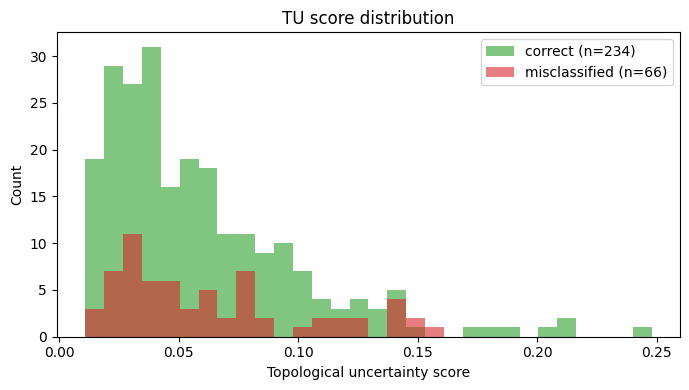

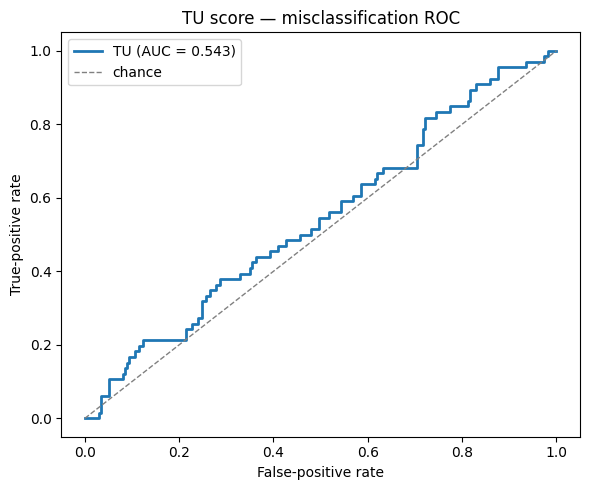

In [5]:
from tanc.visualisation import plot_tu_score_distribution, plot_tu_roc
plot_tu_score_distribution(scores, y_true=y_te, y_pred=test_preds)
if (y_te != test_preds).sum() > 0 and (y_te == test_preds).sum() > 0:
    plot_tu_roc(scores, y_true=y_te, y_pred=test_preds)
else:
    print('All-correct or all-wrong on this small test slice; ROC undefined.')


a curve above the diagonal / AUC > 0.5 means you could catch the net's errors by thresholding TU alone

## Notes & gaps

* Implements the method as described,: per-sample TU on real MNIST activations from a briefly-trained MLP, plus histogram and misclassification ROC.
* The paper's CIFAR-10 / GNN experiments follow the same flow — swap the loader and the model and the rest stays the same.


## Deviations from the paper

Everything this notebook does differently from the source, and why. An empty
table below means the construction follows the paper as written — that is a
claim, not an omission. Scale always differs; see the last row.

| aspect | the paper | this notebook | why it matters |
|---|---|---|---|
| scale | the paper's full experimental setup | a smaller model, fewer samples, fewer epochs | to keep the notebook runnable in minutes; expect weaker effects than published |
